In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from math import factorial

In [2]:
def poisson(n, lam):
    return (lam ** n) * np.exp(-lam) / factorial(n)

POISSON_UPPER_BOUND = 11
poisson_cache = dict()

def poisson_prob(n, lam):
    if (n, lam) not in poisson_cache:
        poisson_cache[(n, lam)] = poisson(n, lam)
    
    return poisson_cache[(n, lam)]

In [3]:
MAX_CARS = 20
MAX_MOVE = 5

REQUEST_LAM = [3, 4]
RETURN_LAM  = [3, 2]

RENT_REWARD = 10
MOVE_COST = 2
GAMMA = 0.9

In [4]:
def expected_return(state, action, V):
    ret = -MOVE_COST * abs(action)
    cars1 = min(state[0] - action, MAX_CARS)
    cars2 = min(state[1] + action, MAX_CARS)

    for req1 in range(POISSON_UPPER_BOUND):
        for req2 in range(POISSON_UPPER_BOUND):
            prob_req = poisson_prob(req1, REQUEST_LAM[0]) * poisson_prob(req2, REQUEST_LAM[1])

            real_req1 = min(cars1, req1)
            real_req2 = min(cars2, req2)
            reward = (real_req1 + real_req2) * RENT_REWARD

            cars1_rem = cars1 - real_req1
            cars2_rem = cars2 - real_req2

            for ret1 in range(POISSON_UPPER_BOUND):
                for ret2 in range(POISSON_UPPER_BOUND):
                    prob_ret = poisson_prob(ret1, RETURN_LAM[0]) * poisson_prob(ret2, RETURN_LAM[1])

                    next_cars1 = min(cars1_rem + ret1, MAX_CARS)
                    next_cars2 = min(cars2_rem + ret2, MAX_CARS)

                    ret += prob_req * prob_ret * (
                        reward + GAMMA * V[next_cars1, next_cars2]
                    )
    return ret

In [5]:
V = np.zeros((MAX_CARS + 1, MAX_CARS + 1))
policy = np.zeros_like(V, dtype=int)

stable = False

while not stable:
    # Policy Evaluation
    while True:
        delta = 0
        for i in range(MAX_CARS + 1):
            for j in range(MAX_CARS + 1):
                v = V[i, j]
                V[i, j] = expected_return((i, j), policy[i, j], V)
                delta = max(delta, abs(v - V[i, j]))
        if delta < 1e-3:
            break

    # Policy Improvement
    stable = True
    for i in range(MAX_CARS + 1):
        for j in range(MAX_CARS + 1):
            old_action = policy[i, j]
            actions = range(-min(j, MAX_MOVE), min(i, MAX_MOVE) + 1)
            values = [expected_return((i, j), a, V) for a in actions]
            policy[i, j] = actions[np.argmax(values)]
            if old_action != policy[i, j]:
                stable = False

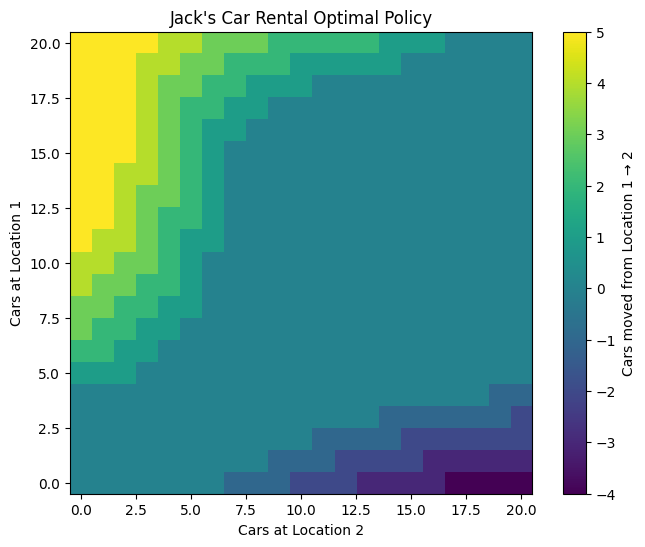

In [6]:
plt.figure(figsize=(8,6))
plt.imshow(policy, origin='lower')
plt.colorbar(label="Cars moved from Location 1 → 2")
plt.xlabel("Cars at Location 2")
plt.ylabel("Cars at Location 1")
plt.title("Jack's Car Rental Optimal Policy")
plt.show()